<a href="https://colab.research.google.com/github/dinhvhung/Machine_Learning/blob/nghia/ML_DataPreprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kích thước dữ liệu ban đầu: 20640 dòng, 10 cột

Số lượng dòng bị thiếu 'total_bedrooms' ban đầu: 207
Số lượng dòng bị thiếu sau xử lý: 0



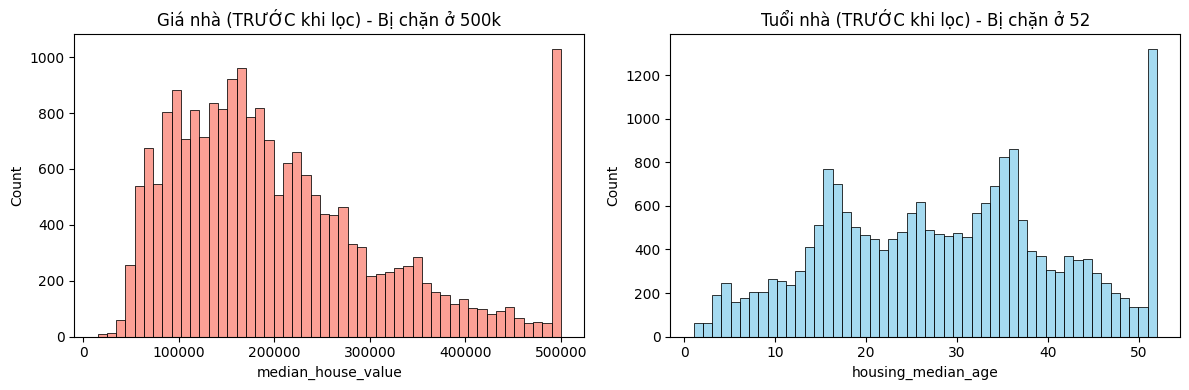

--------------------------------------------------
Kích thước dữ liệu SẠCH: 18572 dòng, 10 cột
Đã loại bỏ: 2068 dòng dữ liệu bị nhiễu/chặn.
--------------------------------------------------


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('housing.csv')
print(f"Kích thước dữ liệu ban đầu: {df.shape[0]} dòng, {df.shape[1]} cột\n")

missing_count = df['total_bedrooms'].isnull().sum()
print(f"Số lượng dòng bị thiếu 'total_bedrooms' ban đầu: {missing_count}")

median_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)

print(f"Số lượng dòng bị thiếu sau xử lý: {df['total_bedrooms'].isnull().sum()}\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['median_house_value'], bins=50, ax=axes[0], color='salmon')
axes[0].set_title('Giá nhà (TRƯỚC khi lọc) - Bị chặn ở 500k')

sns.histplot(df['housing_median_age'], bins=50, ax=axes[1], color='skyblue')
axes[1].set_title('Tuổi nhà (TRƯỚC khi lọc) - Bị chặn ở 52')
plt.tight_layout()
plt.show()

df_cleaned = df[(df['median_house_value'] < 500001) & (df['housing_median_age'] < 52)].copy()

print("-" * 50)
print(f"Kích thước dữ liệu SẠCH: {df_cleaned.shape[0]} dòng, {df_cleaned.shape[1]} cột")
print(f"Đã loại bỏ: {df.shape[0] - df_cleaned.shape[0]} dòng dữ liệu bị nhiễu/chặn.")
print("-" * 50)

df = df_cleaned.copy()

In [ ]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

df_encoded = pd.get_dummies(df, columns=['ocean_proximity'])
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
        df_encoded[col] = df_encoded[col].astype(int)
print(f"Kích thước dữ liệu MỚI: {df_encoded.shape[0]} dòng, {df_encoded.shape[1]} cột")
print("\nDanh sách các cột hiện có sẵn sàng cho mô hình:")
print(df_encoded.columns.tolist())

df = df_encoded.copy()

Kích thước dữ liệu MỚI: 18572 dòng, 17 cột

Danh sách các cột hiện có sẵn sàng cho mô hình:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [ ]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.7 MB/s eta 0:00:00


In [ ]:
import osmnx as ox
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree
import warnings
import time

warnings.filterwarnings('ignore')

# Cấu hình tăng thời gian chờ để không bị văng lỗi Timeout
ox.settings.timeout = 1500
ox.settings.requests_timeout = 1500

print("1. Đang tải dữ liệu bản đồ (Dùng chiến thuật chia nhỏ theo Quận để không bị sập server)...")
tags = {'amenity': ['school', 'hospital'], 'shop': ['supermarket']}

# Lọc 7 hạt (County) đông dân nhất California, bao phủ 90% dữ liệu nhà của bạn
counties = [
    'Los Angeles County, California, USA',
    'San Diego County, California, USA',
    'Orange County, California, USA',
    'Santa Clara County, California, USA',
    'San Francisco, California, USA',
    'Alameda County, California, USA',
    'Sacramento County, California, USA'
]

gdf_list = []
for county in counties:
    print(f" -> Đang cào dữ liệu tại: {county}...")
    try:
        # Dùng hàm features_from_place chuẩn của phiên bản mới
        gdf = ox.features_from_place(county, tags=tags)
        gdf_list.append(gdf)
        time.sleep(2) # Nghỉ 2 giây để tránh bị máy chủ khóa IP
    except Exception as e:
        print(f"    [!] Bỏ qua {county} do lỗi mạng: {e}")

if len(gdf_list) == 0:
    raise ValueError("Không tải được dữ liệu nào, server đang quá tải. Hãy thử lại sau 5 phút.")

# Gộp toàn bộ POI lại
pois = pd.concat(gdf_list)
print(f"\n2. Đã tải xong! Thu được tổng cộng {len(pois)} địa điểm. Đang trích xuất tọa độ...")

pois_points = pois.geometry.centroid
category_col = pois['amenity'].combine_first(pois.get('shop'))
pois_df = pd.DataFrame({'category': category_col, 'latitude': pois_points.y, 'longitude': pois_points.x}).dropna()

real_schools = pois_df[pois_df['category'] == 'school']
real_hospitals = pois_df[pois_df['category'] == 'hospital']
real_supermarkets = pois_df[pois_df['category'] == 'supermarket']

print("3. Đang xây dựng cây không gian (BallTree) và tính toán khoảng cách...")
df_coords_rad = np.radians(df[['latitude', 'longitude']].values)

tree_school = BallTree(np.radians(real_schools[['latitude', 'longitude']].values), metric='haversine')
tree_hospital = BallTree(np.radians(real_hospitals[['latitude', 'longitude']].values), metric='haversine')
tree_supermarket = BallTree(np.radians(real_supermarkets[['latitude', 'longitude']].values), metric='haversine')

print("4. Đang LƯU TRỰC TIẾP các cột mới vào biến df của bạn...")
# ĐÂY LÀ BƯỚC GHI THẲNG VÀO BIẾN DF
df['dist_to_real_school_km'] = tree_school.query(df_coords_rad, k=1)[0].flatten() * 6371.0
df['dist_to_real_hospital_km'] = tree_hospital.query(df_coords_rad, k=1)[0].flatten() * 6371.0
df['dist_to_real_supermarket_km'] = tree_supermarket.query(df_coords_rad, k=1)[0].flatten() * 6371.0

print("-" * 50)
print("✅ HOÀN THÀNH TỐT ĐẸP!")
print(f"Biến df đã được cập nhật. Kích thước hiện tại: {df.shape[0]} dòng, {df.shape[1]} cột")

1. Đang tải dữ liệu bản đồ (Dùng chiến thuật chia nhỏ theo Quận để không bị sập server)...
 -> Đang cào dữ liệu tại: Los Angeles County, California, USA...
    [!] Bỏ qua Los Angeles County, California, USA do lỗi mạng: HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x7ac35ed068d0>: Failed to establish a new connection: [Errno 111] Connection refused'))
 -> Đang cào dữ liệu tại: San Diego County, California, USA...
    [!] Bỏ qua San Diego County, California, USA do lỗi mạng: HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x7ac35eeb3350>: Failed to establish a new connection: [Errno 111] Connection refused'))
 -> Đang cào dữ liệu tại: Orange County, California, USA...
 -> Đang cào dữ liệu tại: Santa Clara County, California,

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.neighbors import BallTree, KernelDensity

print("Đang xử lý các Siêu đặc trưng Không gian (Advanced Spatial Features)...")

# Chuyển đổi toàn bộ tọa độ sang Radian để tính toán trên mặt cầu Trái Đất
df_coords_rad = np.radians(df[['latitude', 'longitude']].values)

cities = {
    'LA': (34.0522, -118.2437), 'SF': (37.7749, -122.4194),
    'SD': (32.7157, -117.1611), 'SJ': (37.3382, -121.8863)
}

def haversine_fast(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
    return 6371.0 * (2 * np.arcsin(np.sqrt(a)))

# Tính khoảng cách đến cả 4 thành phố, sau đó lấy giá trị nhỏ nhất (min)
for city, (lat, lon) in cities.items():
    df[f'dist_to_{city}'] = haversine_fast(df['latitude'], df['longitude'], lat, lon)

df['dist_to_nearest_major_city'] = df[[f'dist_to_{city}' for city in cities.keys()]].min(axis=1)

# Xóa các cột khoảng cách riêng lẻ để dọn rác, chỉ giữ lại cột "gần nhất"
df = df.drop(columns=[f'dist_to_{city}' for city in cities.keys()])
print("✓ Đã tính: Khoảng cách tới Thành phố lớn gần nhất.")

# Chia California thành 15 vùng kinh tế
kmeans = KMeans(n_clusters=15, random_state=42, n_init=10)
df['economic_region'] = kmeans.fit_predict(df[['latitude', 'longitude']])

# Phải One-Hot Encoding biến này để Linear Regression và XGBoost không hiểu lầm thứ tự
df = pd.get_dummies(df, columns=['economic_region'])
print("✓ Đã tính: Phân lô 15 vùng kinh tế địa lý (One-Hot Encoded).")

house_tree = BallTree(df_coords_rad, metric='haversine')
prices = df['median_house_value'].values
incomes = df['median_income'].values

radius_5km_rad = 5.0 / 6371.0
indices_5km = house_tree.query_radius(df_coords_rad, r=radius_5km_rad)
df['avg_price_5km'] = np.array([prices[idx].mean() if len(idx) > 0 else 0 for idx in indices_5km])

_, indices_10nn = house_tree.query(df_coords_rad, k=11)
df['median_income_10nn'] = np.array([incomes[idx[1:]].mean() for idx in indices_10nn])

df['wealth_ratio'] = df['median_income'] / (df['median_income_10nn'] + 0.001)
print("✓ Đã tính: Đặc trưng lân cận (avg_price_5km, median_income_10nn, wealth_ratio).")

top_10_threshold = df['median_house_value'].quantile(0.90)
top_10_coords_rad = df_coords_rad[df['median_house_value'] >= top_10_threshold]

kde = KernelDensity(bandwidth=0.01, metric='haversine', kernel='gaussian')
kde.fit(top_10_coords_rad)

df['luxury_density_score'] = np.exp(kde.score_samples(df_coords_rad))
print("✓ Đã tính: Điểm mật độ nhà giàu (luxury_density_score) bằng KDE.")

for col in df.columns:
    if df[col].dtype == bool:
        df[col] = df[col].astype(int)

print("🎉 HOÀN TẤT TOÀN BỘ GIAI ĐOẠN 3!")
print(f"Kích thước bộ dữ liệu siêu cấp của bạn: {df.shape[0]} dòng, {df.shape[1]} cột")
print(df.head())

Đang xử lý các Siêu đặc trưng Không gian (Advanced Spatial Features)...
✓ Đã tính: Khoảng cách tới Thành phố lớn gần nhất.
✓ Đã tính: Phân lô 15 vùng kinh tế địa lý (One-Hot Encoded).
✓ Đã tính: Đặc trưng lân cận (avg_price_5km, median_income_10nn, wealth_ratio).
✓ Đã tính: Điểm mật độ nhà giàu (luxury_density_score) bằng KDE.
🎉 HOÀN TẤT TOÀN BỘ GIAI ĐOẠN 3!
Kích thước bộ dữ liệu siêu cấp của bạn: 18572 dòng, 40 cột
    longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0     -122.23     37.88                41.0        880.0           129.0   
1     -122.22     37.86                21.0       7099.0          1106.0   
8     -122.26     37.84                42.0       2555.0           665.0   
15    -122.26     37.85                50.0       1120.0           283.0   
18    -122.26     37.84                50.0       2239.0           455.0   

    population  households  median_income  median_house_value  \
0        322.0       126.0         8.3252            45260

In [ ]:
cols_to_drop = [f'economic_region_{i}' for i in range(15)]
df = df.drop(columns=cols_to_drop)

In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,...,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,dist_to_real_school_km,dist_to_real_hospital_km,dist_to_real_supermarket_km,dist_to_nearest_major_city,avg_price_5km,median_income_10nn,wealth_ratio,luxury_density_score
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,...,1,0,13.401237,18.314827,13.696175,20.329542,296590.697674,5.70773,1.458328,434.404187
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,...,1,0,13.426444,18.083976,13.729104,19.908065,303596.428571,5.59532,1.483368,441.071117
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,4.294118,...,1,0,9.514450,13.993512,9.816938,15.763967,184048.623853,1.70314,1.220792,445.731656
15,-122.26,37.85,50.0,1120.0,283.0,697.0,264.0,2.1250,140000.0,4.242424,...,1,0,9.745107,14.423645,10.047945,16.303707,208023.157895,1.78646,1.188838,442.750005
18,-122.26,37.84,50.0,2239.0,455.0,990.0,419.0,1.9911,158700.0,5.343675,...,1,0,9.514450,13.993512,9.816938,15.763967,184048.623853,1.70314,1.168390,445.731656


In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')
folder_path = '/content/drive/MyDrive/ML_Projects'
file_name = 'california_housing_FINAL_ready.csv'
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f" Đã tạo thư mục mới trên Drive: {folder_path}")

full_path = os.path.join(folder_path, file_name)
df.to_csv(full_path, index=False)
print(f"Đã lưu file CSV vào: {full_path}")


Mounted at /content/drive
 Đã tạo thư mục mới trên Drive: /content/drive/MyDrive/ML_Projects
Đã lưu file CSV vào: /content/drive/MyDrive/ML_Projects/california_housing_FINAL_ready.csv
